### Packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm


In [3]:
claims_pivot = pd.read_csv("claims_pivot.csv")
codes_df = pd.read_excel("Codes Manual.xlsx")


In [4]:
claims_pivot = pd.read_csv(
    "claims_pivot.csv",
    index_col=0,
    parse_dates=[0]
)

claims_pivot.index.name = "CLAIM_FROM_MONTH"

In [5]:
claims_pivot

,0295T,0296T,0297T,0298T,0464T,11100,11101,11102,11103,11104,...,96127,96130,96131,96132,96133,96136,96137,96138,96139,96146
CLAIM_FROM_MONTH,,,,,,,,,,,,,,,,,,,,,
2018-01-01,NaN,45.0,566.0,88.0,NaN,10190.0,1047.0,NaN,NaN,NaN,...,146929.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-01,NaN,108.0,705.0,192.0,NaN,9802.0,1176.0,NaN,NaN,NaN,...,139342.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01,14.0,112.0,908.0,276.0,NaN,11276.0,1254.0,NaN,NaN,NaN,...,160875.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-04-01,15.0,106.0,889.0,191.0,NaN,11231.0,1243.0,NaN,NaN,NaN,...,162667.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-05-01,14.0,188.0,1048.0,183.0,NaN,12689.0,1431.0,NaN,NaN,NaN,...,170539.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10805.0,1235.0,1222.0,...,519961.0,33999.0,16529.0,8561.0,4493.0,17752.0,12019.0,9833.0,4186.0,415.0
2024-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10266.0,959.0,1105.0,...,497491.0,33454.0,16023.0,8992.0,4238.0,16747.0,11373.0,10051.0,4099.0,487.0
2024-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11942.0,1400.0,1122.0,...,529734.0,35431.0,16561.0,9451.0,4221.0,17000.0,11737.0,11862.0,4142.0,572.0


### Aggregates

In [6]:
# helper: sum listed code columns, treating missing columns as 0
def agg_codes(df, codes):
    return df.reindex(columns=codes, fill_value=0).fillna(0).sum(axis=1)

agg_map = {
    "Agg_autonomic_testing": ["95921", "95922", "95923", "95924"],
    "Agg_skin_biopsy": ["11100", "11101", "11102", "11103", "11104", "11105", "11106", "11107"],
    "Agg_cardiac_monitoring": ["0295T", "0296T", "0297T", "0298T", "93241", "93242", "93243", "93244", "93245", "93246", "93247", "93248"],
    "Agg_fractures": ["23500", "23600", "25600", "27500", "27750", "27786", "28470", "21310", "28510", "25605", "24670", "27236", "24546", "25606", "27235"],
    "Agg_nerve_conduction": ["95907", "95908", "95909", "95910", "95911", "95912", "95913"],
    "Agg_neurophysiologic/autonomic testing": ["95943", "95999"],
    "Agg_immunohistochemistry_stains": ["88341", "88342"],
    "Agg_psychological_testing": ["96130", "96131", "96132", "96133", "96134", "96135", "96136", "96137", "96138", "96139", "96146"],
    "Agg_neurobehavioral": ["96116", "96121"],
    "Agg_needle_EMG": ["95886", "95887"],
    "Agg_clotting":["85240", "85241", "85242", "85243", "85244", "85245", "85246", "85247", "85248", "85249", "85250", "85251", "85252", "85253", "85254", "85255", "85256", "85257", "85258", "85259", "85260", "85261", "85262", "85263", "85264", "85265", "85266", "85267", "85268", "85269", "85270"],
    "Agg_pregnancy_test": ["81025", "84073"],
    "Agg_fluorescent_noninfectious_agent": ["86383", "86051", "86052", "86053", "86255", "86256"],

}

for new_col, codes in agg_map.items():
    claims_pivot[new_col] = agg_codes(claims_pivot, codes)


In [7]:
#robust toggle:
robust = True

non_robust = claims_pivot.copy()
#drop mach-may 2020
if robust:
    claims_pivot = claims_pivot[~claims_pivot.index.isin(pd.date_range("2020-03-01", "2020-05-31"))]


### ITS

$Y_tâ€‹=B_0â€‹+B_1â€‹T+B_2â€‹X_tâ€‹+B_3â€‹(X_tâ€‹â‹…T)$

In [8]:
code = "Agg_autonomic_testing"
intervention_month = pd.Timestamp("2021-01-01")

ts = claims_pivot[[code]].reset_index()
ts.columns = ["month", "y"]

# start at first non-zero month so leading missing months are excluded
nonzero_idx = ts.index[ts["y"].fillna(0) > 0]
if len(nonzero_idx) > 0:
    ts = ts.loc[nonzero_idx[0]:].reset_index(drop=True)

ts["y"] = ts["y"].fillna(0)

# calendar-month index (preserves real time gaps if months are dropped)
ts["_month_index"] = ts["month"].dt.year * 12 + ts["month"].dt.month
ts["T"] = ts["_month_index"] - ts["_month_index"].iloc[0]

# intervention dummy
intervention_month = pd.Timestamp(intervention_month)
ts["X_t"] = (ts["month"] >= intervention_month).astype(int)

# calendar months since intervention (1 in intervention month)
intervention_month_index = intervention_month.year * 12 + intervention_month.month
ts["T'"] = 0
post_mask = ts["month"] >= intervention_month
if post_mask.any():
    ts.loc[post_mask, "T'"] = ts.loc[post_mask, "_month_index"] - intervention_month_index + 1

ts.head(50)

,month,y,_month_index,T,X_t,T'
0,2018-01-01,8113.0,24217,0,0,0
1,2018-02-01,8494.0,24218,1,0,0
2,2018-03-01,8885.0,24219,2,0,0
3,2018-04-01,7886.0,24220,3,0,0
4,2018-05-01,7936.0,24221,4,0,0
5,2018-06-01,7130.0,24222,5,0,0
6,2018-07-01,6681.0,24223,6,0,0
7,2018-08-01,6760.0,24224,7,0,0
8,2018-09-01,5125.0,24225,8,0,0
9,2018-10-01,6683.0,24226,9,0,0


In [9]:
X = sm.add_constant(ts[["T", "X_t", "T'"]])
y = ts["y"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.121
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     3.246
Date:                Mon, 27 Apr 2026   Prob (F-statistic):             0.0269
Time:                        10:59:50   Log-Likelihood:                -627.71
No. Observations:                  75   AIC:                             1263.
Df Residuals:                      71   BIC:                             1273.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7679.0974    351.612     21.840      0.0

In [10]:
X

,const,T,X_t,T'
0,1.0,0,0,0
1,1.0,1,0,0
2,1.0,2,0,0
3,1.0,3,0,0
4,1.0,4,0,0
...,...,...,...,...
70,1.0,73,1,38
71,1.0,74,1,39
72,1.0,75,1,40
73,1.0,76,1,41


In [11]:
def _trim_to_first_nonzero(ts):
    ts = ts.copy()
    ts["month"] = pd.to_datetime(ts["month"])
    ts["y"] = pd.to_numeric(ts["y"], errors="coerce")

    nonzero_idx = ts.index[ts["y"].fillna(0) > 0]
    if len(nonzero_idx) == 0:
        return ts.iloc[0:0].copy()

    start_idx = nonzero_idx[0]
    return ts.loc[start_idx:].reset_index(drop=True)


def fit_its_single(ts, intervention_month):
    ts = _trim_to_first_nonzero(ts)
    if ts.empty:
        raise ValueError("Series has no non-zero observations after trimming leading months.")

    # outcome
    ts["y"] = ts["y"].fillna(0)

    # calendar-month index (preserves real time gaps if months are dropped)
    ts["_month_index"] = ts["month"].dt.year * 12 + ts["month"].dt.month
    ts["T"] = ts["_month_index"] - ts["_month_index"].iloc[0]

    # intervention indicator
    intervention_month = pd.Timestamp(intervention_month)
    ts["X_t"] = (ts["month"] >= intervention_month).astype(int)

    # calendar months since intervention (1 in intervention month)
    intervention_month_index = intervention_month.year * 12 + intervention_month.month
    ts["post_time"] = 0
    post_mask = ts["month"] >= intervention_month
    if post_mask.any():
        ts.loc[post_mask, "post_time"] = ts.loc[post_mask, "_month_index"] - intervention_month_index + 1

    # design matrix
    X = sm.add_constant(ts[["T", "X_t", "post_time"]])
    y = ts["y"]

    # fit model
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 1})

    return model

In [12]:
results = []

intervention_month = pd.Timestamp("2021-01-01")

# Build metadata lookup once
meta_lookup = (
    codes_df.assign(CODE=codes_df["CODE"].astype(str).str.strip())
    .drop_duplicates(subset=["CODE"])
    .set_index("CODE")[["Description"]]
    .to_dict(orient="index")
)

for code in claims_pivot.columns:

    # build time series
    ts = claims_pivot[[code]].reset_index()
    ts.columns = ["month", "y"]
    ts = _trim_to_first_nonzero(ts)

    # skip sparse series
    observed = int(ts["y"].notna().sum())
    if observed < 37:
        print(f"Skipping code {code} due to insufficient data (observed {observed} months)")
        continue

    # get metadata
    code_str = str(code).strip()
    meta = meta_lookup.get(code_str, {})
    desc = meta.get("Description")

    try:
        model = fit_its_single(ts, intervention_month)

        params = model.params
        pvals = model.pvalues
        conf = model.conf_int()

        results.append({
            "HCPCS_CODE": code_str,
            "Description": desc,

            "B0_const": params.get("const", np.nan),
            "B1_time": params.get("T", np.nan),
            "B2_level": params.get("X_t", np.nan),
            "B3_slope": params.get("post_time", np.nan),

            "p_const": pvals.get("const", np.nan),
            "p_time": pvals.get("T", np.nan),
            "p_level": pvals.get("X_t", np.nan),
            "p_slope": pvals.get("post_time", np.nan),

            "ci_const_low": conf.loc["const", 0] if "const" in conf.index else np.nan,
            "ci_const_high": conf.loc["const", 1] if "const" in conf.index else np.nan,

            "ci_time_low": conf.loc["T", 0] if "T" in conf.index else np.nan,
            "ci_time_high": conf.loc["T", 1] if "T" in conf.index else np.nan,

            "ci_level_low": conf.loc["X_t", 0] if "X_t" in conf.index else np.nan,
            "ci_level_high": conf.loc["X_t", 1] if "X_t" in conf.index else np.nan,

            "ci_slope_low": conf.loc["post_time", 0] if "post_time" in conf.index else np.nan,
            "ci_slope_high": conf.loc["post_time", 1] if "post_time" in conf.index else np.nan,

            "R_squared": model.rsquared,
            "N_obs": observed
        })

    except Exception as e:
        results.append({
            "HCPCS_CODE": code_str,
            "Description": desc,
            "ERROR": str(e)
        })


Skipping code 0295T due to insufficient data (observed 28 months)
Skipping code 0296T due to insufficient data (observed 33 months)
Skipping code 0297T due to insufficient data (observed 33 months)
Skipping code 0298T due to insufficient data (observed 33 months)
Skipping code 0464T due to insufficient data (observed 2 months)
Skipping code 11100 due to insufficient data (observed 13 months)
Skipping code 11101 due to insufficient data (observed 12 months)
Skipping code 21310 due to insufficient data (observed 18 months)
Skipping code 23600 due to insufficient data (observed 1 months)
Skipping code 27500 due to insufficient data (observed 11 months)
Skipping code 27750 due to insufficient data (observed 35 months)
Skipping code 28510 due to insufficient data (observed 34 months)
Skipping code 38505 due to insufficient data (observed 29 months)
Skipping code 38525 due to insufficient data (observed 11 months)
Skipping code 75557 due to insufficient data (observed 31 months)
Skipping cod

In [213]:
results_df = pd.DataFrame(results)

# optional sorting
results_df = results_df.sort_values("p_level")

def smart_format(x):
    if pd.isna(x):
        return ""
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        if x == 0:
            return "0.0000"
        if abs(x) < 1e-4:
            return f"{x:.2E}"
        return f"{x:.4f}"
    return x

for col in results_df.columns:
    if pd.api.types.is_numeric_dtype(results_df[col]):
        results_df[col] = results_df[col].apply(smart_format)

#replace nan with 0
results_df = results_df.replace("nan", 0)
results_df = results_df.replace("", 0)
results_df

,HCPCS_CODE,Description,B0_const,B1_time,B2_level,B3_slope,p_const,p_time,p_level,p_slope,ci_const_low,ci_const_high,ci_time_low,ci_time_high,ci_level_low,ci_level_high,ci_slope_low,ci_slope_high,R_squared,N_obs
96,93247,continuous cardiac monitoring and detection,0,-857.3050,1792.9227,935.6177,0,1.45E-76,1.11E-94,2.79E-117,0,0,-948.0387,-766.5712,1622.6998,1963.1455,855.9653,1015.2701,0.8021,42
93,93243,continuous cardiac monitoring and detection,0,-692.4881,1483.4666,790.9786,0,5.44E-49,5.04E-63,9.47E-81,0,0,-784.7460,-600.2301,1309.9543,1656.9790,709.5166,872.4405,0.8497,42
95,93246,continuous cardiac monitoring and detection,0,-129.9846,300.5532,170.5686,0,6.98E-10,2.82E-14,2.64E-20,0,0,-171.2993,-88.6698,223.1098,377.9965,134.3585,206.7787,0.8313,42
55,86140,CRP,142410.7339,2107.1289,36591.4760,-1945.9488,0.0000,8.44E-43,3.69E-11,2.57E-13,135046.4851,149774.9827,1805.9714,2408.2865,25751.3954,47431.5567,-2467.3104,-1424.5872,0.8819,75
97,93248,continuous cardiac monitoring and detection,0,-132.3011,310.3377,178.0366,0,8.35E-07,9.41E-10,9.46E-14,0,0,-184.9294,-79.6727,210.9366,409.7388,131.1870,224.8862,0.8057,42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39,85250,Clotting factors (selective use),59.5003,2.1284,-2.1905,2.1720,2.09E-39,1.03E-22,0.8561,8.50E-05,50.6216,68.3790,1.7031,2.5537,-25.8617,21.4807,1.0888,3.2552,0.8136,75
126,96127,"Brief emotional/behavioral assessment, per st...",149097.7078,5606.2088,3567.4631,-1282.6675,6.25E-56,9.49E-21,0.8863,0.2183,130550.7203,167644.6952,4429.9688,6782.4489,-45346.5425,52481.4687,-3324.8983,759.5634,0.8115,75
78,92552,Pure tone audiogram,61318.6101,1035.3203,-1007.5073,-1241.0980,3.10E-26,0.0005,0.9175,0.0040,49976.7073,72660.5128,455.9809,1614.6597,-20073.4501,18058.4355,-2086.9014,-395.2946,0.2126,75
19,75574,Cardiac CTA,261.5799,16.4551,-4.0632,37.4710,1.48E-36,2.32E-41,0.9629,3.28E-21,220.9812,302.1786,14.0610,18.8493,-175.4369,167.3104,29.7022,45.2397,0.9313,75


In [214]:
results_df.to_csv("its_results.csv", index=False)

### Plots

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     70.60
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           2.91e-21
Time:                        11:01:23   Log-Likelihood:                -428.26
No. Observations:                  75   AIC:                             864.5
Df Residuals:                      71   BIC:                             873.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         51.3632     24.613      2.087      0.0

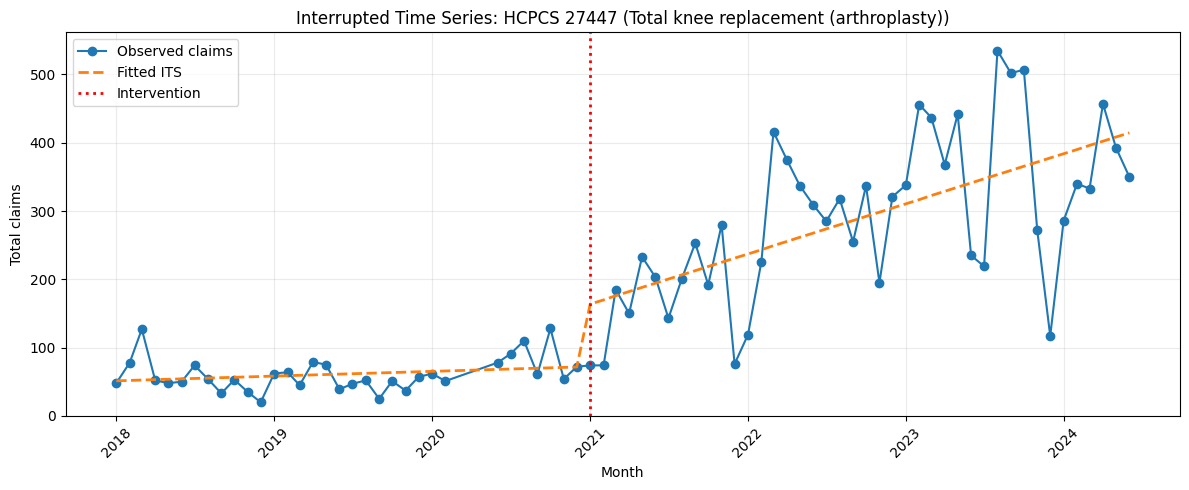

In [ ]:
def plot_interrupted_time_series(claims_pivot, code, intervention_month, fill_missing=0, figsize=(12, 5)):
    code = str(code).strip()

    ts = claims_pivot[[code]].reset_index()
    ts.columns = ["month", "y"]
    ts = _trim_to_first_nonzero(ts)
    if ts.empty:
        raise ValueError(f"Series {code} has no non-zero observations after trimming leading months.")
    ts["y"] = ts["y"].fillna(fill_missing)

    # calendar-month index (preserves real time gaps if months are dropped)
    ts["_month_index"] = ts["month"].dt.year * 12 + ts["month"].dt.month
    ts["T"] = ts["_month_index"] - ts["_month_index"].iloc[0]

    # intervention dummy
    intervention_month = pd.Timestamp(intervention_month)
    ts["X_t"] = (ts["month"] >= intervention_month).astype(int)

    # calendar months since intervention (1 in intervention month)
    intervention_month_index = intervention_month.year * 12 + intervention_month.month
    ts["T'"] = 0
    post_mask = ts["month"] >= intervention_month
    if post_mask.any():
        ts.loc[post_mask, "T'"] = ts.loc[post_mask, "_month_index"] - intervention_month_index + 1

    X = sm.add_constant(ts[["T", "X_t", "T'"]])
    y = ts["y"]

    model = sm.OLS(y, X).fit()
    ts["y_hat"] = model.predict(X)

    desc = None
    if "codes_df" in globals() and {"CODE", "Description"}.issubset(codes_df.columns):
        meta = codes_df.assign(CODE=codes_df["CODE"].astype(str).str.strip())
        match = meta.loc[meta["CODE"] == code, "Description"]
        if not match.empty:
            desc = match.iloc[0]

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(ts["month"], ts["y"], marker="o", linewidth=1.5, label="Observed claims")
    ax.plot(ts["month"], ts["y_hat"], linestyle="--", linewidth=2, label="Fitted ITS")
    ax.axvline(intervention_month, color="red", linestyle=":", linewidth=2, label="Intervention")
    ax.set_xlabel("Month")
    ax.set_ylabel("Total claims")
    y_max = float(np.nanmax(np.r_[ts["y"].to_numpy(dtype=float), ts["y_hat"].to_numpy(dtype=float), [0.0]]))
    ax.set_ylim(0, y_max * 1.05 if y_max > 0 else 1.0)
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.2f}".rstrip("0").rstrip(".")))

    title = f"Interrupted Time Series: HCPCS {code}"
    if desc:
        title = f"{title} ({desc})"
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.25)
    plt.xticks(rotation=45)
    plt.tight_layout()

    return ts, model, fig, ax


# Example
ts, model, fig, ax = plot_interrupted_time_series(
    claims_pivot=claims_pivot,
    code="agg",
    intervention_month=pd.Timestamp("2021-01-01")
)

print(model.summary())

### All Codes -> PowerPoint

Run the next cell to create one slide per HCPCS code with the ITS plot and OLS summary.


In [216]:
from pathlib import Path
import re
import shutil
import tempfile


def _safe_code_label(code):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(code).strip())


CATEGORY_ORDER = [
    "AUTONOMIC TESTING",
    "ADDITIONAL/ADJUNCT AUTONOMIC TESTING",
    "SMALL FIBER NEUROPATHY TESTING",
    "QUANTITATIVE SENSORY TESTING",
    "SUDOMOTOR TESTING",
    "NERVE CONDUCTION STUDIES",
    "AUTONOMIC + CARDIOVASCULAR MONITORING",
    "CORE MAST CELL MEDIATOR TESTING",
    "URINARY MEDIATORS",
    "COMPLEMENT/INFLAMMATORY OVERLAP",
    "CYTOKINE/IMMUNE ACTIVATION",
    "AUTOIMMUNE SCREENING",
    "LYMPHOCYTE SUBSETS/IMMUNE PHENOTYPING",
    "VIRAL REACTIVATION",
    "STANDARD COAGULATION PANEL",
    "FIBRINOLYSIS/CLOT STABILITY",
    "PLATELET FUNCTION/ACTIVATION",
    "HYPERCOAGULABILITY/ENDOTHELIAL INJURY",
    "CARDIAC IMAGING",
    "CARDIAC MONITORING",
    "NEGATIVE CONTROL",
    "TINNITUS",
    "ADDITIONAL",
]
CATEGORY_INDEX = {name: idx for idx, name in enumerate(CATEGORY_ORDER)}


def _normalize_category(category_value):
    if pd.isna(category_value) or not str(category_value).strip():
        return "ADDITIONAL"
    normalized = " ".join(str(category_value).strip().upper().split())
    return normalized if normalized in CATEGORY_INDEX else "ADDITIONAL"


def _code_sort_key(code_value):
    code = str(code_value).strip().upper()
    exact = re.match(r"^(\\d+)([A-Z]*)$", code)
    if exact:
        return (0, int(exact.group(1)), exact.group(2), code)
    prefix = re.match(r"^(\\d+)", code)
    if prefix:
        return (1, int(prefix.group(1)), code)
    return (2, float("inf"), code)


def _order_payloads(payloads):
    return sorted(
        payloads,
        key=lambda item: (
            CATEGORY_INDEX.get(item.get("category", "ADDITIONAL"), CATEGORY_INDEX["ADDITIONAL"]),
            _code_sort_key(item.get("code", "")),
        ),
    )


def _build_metadata_lookup():
    if "codes_df" in globals() and "CODE" in codes_df.columns:
        meta = (
            codes_df.assign(CODE=codes_df["CODE"].astype(str).str.strip())
            .drop_duplicates(subset=["CODE"])
        )
        available_fields = [col for col in ["Description", "Category"] if col in meta.columns]
        if available_fields:
            return meta.set_index("CODE")[available_fields].to_dict(orient="index")
    return {}


def _clean_summary_text(summary_text, drop_notes=True):
    text = str(summary_text)
    text = text.replace(chr(13) + chr(10), chr(10))
    marker = chr(10) + "Notes:" + chr(10)
    if drop_notes and marker in text:
        text = text.split(marker, 1)[0].rstrip()
    return text


def _pick_font_size(summary_text, box_width_pts, box_height_pts):
    # Monospace estimate: char width ~ 0.60 * font_size, line height ~ 1.20 * font_size
    lines = summary_text.splitlines() or [""]
    max_len = max(len(line) for line in lines)
    line_count = len(lines)

    for size in (12, 11, 10, 9, 8, 7, 6):
        max_chars = box_width_pts / (0.60 * size)
        max_lines = box_height_pts / (1.20 * size)
        if max_len <= max_chars and line_count <= max_lines:
            return size

    return 6


def _normalize_code(code_value):
    return str(code_value).strip().upper()


def _pretty_aggregate_title(aggregate_code):
    code = str(aggregate_code).strip()
    name = re.sub(r"(?i)^agg_", "", code)
    name = re.sub(r"[_/]+", " ", name)
    name = re.sub(r"\s+", " ", name).strip()
    if not name:
        return "Aggregate"
    words = []
    for token in name.split(" "):
        if token.isupper():
            words.append(token)
        elif token.islower():
            words.append(token.capitalize())
        else:
            words.append(token)
    return "Aggregate " + " ".join(words)


def _build_aggregate_code_lookup():
    raw_map = globals().get("agg_map", {})
    if not isinstance(raw_map, dict):
        return {}

    lookup = {}
    for key, values in raw_map.items():
        key_str = str(key).strip()
        if not key_str:
            continue

        if isinstance(values, (list, tuple, set)):
            raw_codes = list(values)
        else:
            raw_codes = [values]

        cleaned_codes = []
        seen = set()
        for value in raw_codes:
            code = _normalize_code(value)
            if not code or code in seen:
                continue
            seen.add(code)
            cleaned_codes.append(code)

        lookup[_normalize_code(key_str)] = cleaned_codes

    return lookup


def _build_aggregate_details_text(all_codes, available_codes_upper):
    if not all_codes:
        return "Aggregate Components\nAll codes: (not provided in agg_map)\nMissing codes: (unknown)"

    missing_codes = [code for code in all_codes if code not in available_codes_upper]
    return (
        "Aggregate Components\n"
        f"All codes: {', '.join(all_codes)}\n"
        f"Missing codes: {', '.join(missing_codes) if missing_codes else 'None'}"
    )


def _collect_slide_payloads(
    claims_pivot,
    intervention_month,
    tmp_dir,
    min_observed_months=37,
    fill_missing=0,
):
    meta_lookup = _build_metadata_lookup()
    aggregate_lookup = _build_aggregate_code_lookup()
    available_codes_upper = {_normalize_code(col) for col in claims_pivot.columns}

    payloads = []
    skipped = []
    failed = []

    for idx, code_col in enumerate(claims_pivot.columns, start=1):
        code = str(code_col).strip()
        ts_observed = claims_pivot[[code_col]].reset_index()
        ts_observed.columns = ["month", "y"]
        ts_observed = _trim_to_first_nonzero(ts_observed)
        observed = int(ts_observed["y"].notna().sum())

        if observed < min_observed_months:
            skipped.append((code, observed))
            continue

        try:
            ts, model, fig, ax = plot_interrupted_time_series(
                claims_pivot=claims_pivot,
                code=code_col,
                intervention_month=pd.Timestamp(intervention_month),
                fill_missing=fill_missing,
                figsize=(10, 8),
            )

            plot_path = tmp_dir / f"{idx:04d}_{_safe_code_label(code)}.png"
            fig.savefig(plot_path, dpi=210, bbox_inches="tight", pad_inches=0.01)
            plt.close(fig)

            meta = meta_lookup.get(code, {})
            desc = meta.get("Description")
            category = _normalize_category(meta.get("Category"))
            code_upper = _normalize_code(code)
            aggregate_codes = aggregate_lookup.get(code_upper, [])
            is_aggregate = code_upper.startswith("AGG_")

            if is_aggregate:
                slide_title = _pretty_aggregate_title(code)
            else:
                slide_title = f"HCPCS {code}"
                if pd.notna(desc) and str(desc).strip():
                    slide_title += f" - {str(desc).strip()}"
                slide_title += f" ({observed} months of data)"

            aggregate_details_text = ""
            if is_aggregate:
                aggregate_details_text = _build_aggregate_details_text(
                    all_codes=aggregate_codes,
                    available_codes_upper=available_codes_upper,
                )

            payloads.append(
                {
                    "code": code,
                    "category": category,
                    "observed": observed,
                    "title": slide_title,
                    "plot_path": plot_path,
                    "summary_text": _clean_summary_text(model.summary().as_text(), drop_notes=True),
                    "aggregate_details_text": aggregate_details_text,
                }
            )

        except Exception as e:
            failed.append((code, str(e)))
            plt.close("all")

    payloads = _order_payloads(payloads)
    return payloads, skipped, failed


def _build_summary_lines(output_path, payloads, skipped, failed, engine):
    lines = [
        f"Output: {output_path}",
        f"Engine: {engine}",
        f"Slides created: {len(payloads)}",
        f"Skipped (insufficient data): {len(skipped)}",
        f"Failed: {len(failed)}",
    ]

    if skipped:
        lines.append("")
        lines.append("First skipped codes:")
        lines.extend([f"- {c} (observed={n})" for c, n in skipped[:20]])

    if failed:
        lines.append("")
        lines.append("First failures:")
        lines.extend([f"- {c}: {msg}" for c, msg in failed[:10]])

    return lines


def _export_with_com(output_path, payloads, summary_lines, intervention_month, min_observed_months):
    import pythoncom
    import win32com.client as win32

    PP_LAYOUT_TITLE = 1
    PP_LAYOUT_BLANK = 12
    MSO_TEXT_ORIENTATION_HORIZONTAL = 1

    # 16:9 widescreen in points
    SLIDE_W = 960
    SLIDE_H = 540

    pythoncom.CoInitialize()
    app = None
    presentation = None

    try:
        app = win32.Dispatch("PowerPoint.Application")
        app.Visible = True
        presentation = app.Presentations.Add()

        try:
            presentation.PageSetup.SlideWidth = SLIDE_W
            presentation.PageSetup.SlideHeight = SLIDE_H
        except Exception:
            pass

        slide_w = float(presentation.PageSetup.SlideWidth)
        slide_h = float(presentation.PageSetup.SlideHeight)

        # Title slide
        title_slide = presentation.Slides.Add(1, PP_LAYOUT_TITLE)
        title_slide.Shapes.Title.TextFrame.TextRange.Text = "Interrupted Time Series by HCPCS Code"
        subtitle = title_slide.Shapes.Placeholders(2).TextFrame.TextRange
        subtitle.Text = (
            f"Intervention month: {pd.Timestamp(intervention_month).date()} | "
            f"Minimum observed months: {min_observed_months}"
        )

        current_category = None
        for item in payloads:
            category = item.get("category", "ADDITIONAL")
            if category != current_category:
                current_category = category
                category_slide = presentation.Slides.Add(presentation.Slides.Count + 1, PP_LAYOUT_TITLE)
                category_slide.Shapes.Title.TextFrame.TextRange.Text = current_category
                try:
                    category_slide.Shapes.Placeholders(2).TextFrame.TextRange.Text = ""
                except Exception:
                    pass

            slide = presentation.Slides.Add(presentation.Slides.Count + 1, PP_LAYOUT_BLANK)

            # Fixed two-column layout to match target style
            margin = 14
            gap = 10
            title_h = 38
            content_top = 70
            content_h = slide_h - content_top - margin

            summary_w = slide_w * 0.40
            plot_box_w = slide_w - (margin * 2) - gap - summary_w

            plot_left = margin
            plot_top = content_top
            summary_left = plot_left + plot_box_w + gap
            aggregate_details = str(item.get("aggregate_details_text", "")).strip()
            aggregate_gap = 8
            aggregate_h = min(150, content_h * 0.36) if aggregate_details else 0
            summary_h = content_h - aggregate_h - (aggregate_gap if aggregate_details else 0)

            title_box = slide.Shapes.AddTextbox(
                MSO_TEXT_ORIENTATION_HORIZONTAL,
                margin,
                18,
                slide_w - (margin * 2),
                title_h,
            )
            title_box.TextFrame.TextRange.Text = item["title"]
            title_box.TextFrame.TextRange.Font.Size = 24
            title_box.TextFrame.TextRange.Font.Bold = True

            # Add image at native size, then scale uniformly (preserve aspect ratio)
            pic = slide.Shapes.AddPicture(
                str(item["plot_path"]),
                False,
                True,
                0,
                0,
                -1,
                -1,
            )
            try:
                pic.LockAspectRatio = True
            except Exception:
                pass

            scale = min(plot_box_w / pic.Width, content_h / pic.Height)
            pic.Width = pic.Width * scale
            pic.Height = pic.Height * scale
            pic.Left = plot_left + (plot_box_w - pic.Width) / 2
            pic.Top = plot_top + (content_h - pic.Height) / 2

            summary_box = slide.Shapes.AddTextbox(
                MSO_TEXT_ORIENTATION_HORIZONTAL,
                summary_left,
                content_top,
                summary_w,
                summary_h,
            )
            summary_box.TextFrame.MarginLeft = 0
            summary_box.TextFrame.MarginRight = 0
            summary_box.TextFrame.MarginTop = 0
            summary_box.TextFrame.MarginBottom = 0
            summary_box.TextFrame.WordWrap = False
            summary_box.TextFrame.TextRange.Text = item["summary_text"]
            summary_box.TextFrame.TextRange.Font.Name = "Consolas"
            summary_box.TextFrame.TextRange.Font.Size = _pick_font_size(item["summary_text"], summary_w, summary_h)

            # Ask PowerPoint to shrink text if still needed.
            try:
                summary_box.TextFrame2.AutoSize = 2
            except Exception:
                pass

            if aggregate_details:
                agg_top = content_top + summary_h + aggregate_gap
                agg_box = slide.Shapes.AddTextbox(
                    MSO_TEXT_ORIENTATION_HORIZONTAL,
                    summary_left,
                    agg_top,
                    summary_w,
                    aggregate_h,
                )
                agg_box.TextFrame.MarginLeft = 2
                agg_box.TextFrame.MarginRight = 2
                agg_box.TextFrame.MarginTop = 2
                agg_box.TextFrame.MarginBottom = 2
                agg_box.TextFrame.WordWrap = True
                agg_box.TextFrame.TextRange.Text = aggregate_details
                agg_box.TextFrame.TextRange.Font.Name = "Consolas"
                agg_box.TextFrame.TextRange.Font.Size = 9
                try:
                    agg_box.TextFrame2.AutoSize = 2
                except Exception:
                    pass

        summary_slide = presentation.Slides.Add(presentation.Slides.Count + 1, PP_LAYOUT_BLANK)
        summary_title = summary_slide.Shapes.AddTextbox(MSO_TEXT_ORIENTATION_HORIZONTAL, 24, 18, slide_w - 48, 42)
        summary_title.TextFrame.TextRange.Text = "Build Summary"
        summary_title.TextFrame.TextRange.Font.Size = 26
        summary_title.TextFrame.TextRange.Font.Bold = True

        summary_body = summary_slide.Shapes.AddTextbox(MSO_TEXT_ORIENTATION_HORIZONTAL, 24, 66, slide_w - 48, slide_h - 84)
        summary_body.TextFrame.TextRange.Text = "\n".join(summary_lines)
        summary_body.TextFrame.TextRange.Font.Size = 14

        presentation.SaveAs(str(output_path))

    finally:
        try:
            if presentation is not None:
                presentation.Close()
        finally:
            if app is not None:
                app.Quit()


def _export_with_python_pptx(output_path, payloads, summary_lines, intervention_month, min_observed_months):
    from pptx import Presentation
    from pptx.util import Inches, Pt

    EMU_PER_PT = 12700

    prs = Presentation()
    prs.slide_width = Inches(13.333)
    prs.slide_height = Inches(7.5)

    slide_w = prs.slide_width
    slide_h = prs.slide_height

    # Title slide
    slide = prs.slides.add_slide(prs.slide_layouts[0])
    slide.shapes.title.text = "Interrupted Time Series by HCPCS Code"
    slide.placeholders[1].text = (
        f"Intervention month: {pd.Timestamp(intervention_month).date()} | "
        f"Minimum observed months: {min_observed_months}"
    )

    current_category = None
    for item in payloads:
        category = item.get("category", "ADDITIONAL")
        if category != current_category:
            current_category = category
            category_slide = prs.slides.add_slide(prs.slide_layouts[0])
            category_slide.shapes.title.text = current_category
            try:
                category_slide.placeholders[1].text = ""
            except Exception:
                pass

        s = prs.slides.add_slide(prs.slide_layouts[6])

        # Fixed two-column layout (same visual structure as COM path)
        margin = Inches(0.18)
        gap = Inches(0.12)
        title_h = Inches(0.42)
        content_top = Inches(1.00)
        content_h = slide_h - content_top - margin

        summary_w = int(slide_w * 0.40)
        plot_box_w = slide_w - (margin * 2) - gap - summary_w

        plot_left = margin
        plot_top = content_top
        summary_left = plot_left + plot_box_w + gap
        aggregate_details = str(item.get("aggregate_details_text", "")).strip()
        aggregate_gap = Inches(0.08)
        aggregate_h = min(Inches(1.60), int(content_h * 0.36)) if aggregate_details else 0
        summary_h = content_h - aggregate_h - (aggregate_gap if aggregate_details else 0)

        title_box = s.shapes.add_textbox(margin, Inches(0.15), slide_w - (margin * 2), title_h)
        title_tf = title_box.text_frame
        title_tf.clear()
        p = title_tf.paragraphs[0]
        p.text = item["title"]
        p.font.bold = True
        p.font.size = Pt(24)

        # Add image at native size, then scale uniformly to preserve aspect ratio.
        pic = s.shapes.add_picture(str(item["plot_path"]), 0, 0)
        scale = min(plot_box_w / pic.width, content_h / pic.height)
        pic.width = int(pic.width * scale)
        pic.height = int(pic.height * scale)
        pic.left = int(plot_left + (plot_box_w - pic.width) / 2)
        pic.top = int(plot_top + (content_h - pic.height) / 2)

        summary_box = s.shapes.add_textbox(summary_left, content_top, summary_w, summary_h)
        summary_tf = summary_box.text_frame
        summary_tf.clear()
        summary_tf.word_wrap = False
        summary_tf.margin_left = 0
        summary_tf.margin_right = 0
        summary_tf.margin_top = 0
        summary_tf.margin_bottom = 0

        summary_tf.text = item["summary_text"]
        font_size = _pick_font_size(
            item["summary_text"],
            summary_w / EMU_PER_PT,
            summary_h / EMU_PER_PT,
        )

        for para in summary_tf.paragraphs:
            para.font.name = "Consolas"
            para.font.size = Pt(font_size)

        if aggregate_details:
            agg_top = int(content_top + summary_h + aggregate_gap)
            agg_box = s.shapes.add_textbox(summary_left, agg_top, summary_w, aggregate_h)
            agg_tf = agg_box.text_frame
            agg_tf.clear()
            agg_tf.word_wrap = True
            agg_tf.margin_left = 0
            agg_tf.margin_right = 0
            agg_tf.margin_top = 0
            agg_tf.margin_bottom = 0
            agg_tf.text = aggregate_details
            for para in agg_tf.paragraphs:
                para.font.name = "Consolas"
                para.font.size = Pt(9)

    # Summary slide
    summary_slide = prs.slides.add_slide(prs.slide_layouts[6])

    title_box = summary_slide.shapes.add_textbox(Inches(0.25), Inches(0.2), Inches(6), Inches(0.5))
    title_tf = title_box.text_frame
    title_tf.text = "Build Summary"
    title_tf.paragraphs[0].font.bold = True
    title_tf.paragraphs[0].font.size = Pt(26)

    body_box = summary_slide.shapes.add_textbox(Inches(0.25), Inches(0.9), Inches(12.8), Inches(6.2))
    body_tf = body_box.text_frame
    body_tf.word_wrap = True
    body_tf.text = "\n".join(summary_lines)
    body_tf.paragraphs[0].font.size = Pt(14)

    prs.save(str(output_path))


def build_all_codes_its_powerpoint(
    claims_pivot,
    intervention_month,
    output_path="its_all_codes_report.pptx",
    min_observed_months=37,
    fill_missing=0,
    engine="auto",  # auto | com | python-pptx
):
    output_path = Path(output_path).resolve()
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists():
        output_path.unlink()

    tmp_dir = Path(tempfile.mkdtemp(prefix="its_plots_"))

    try:
        payloads, skipped, failed = _collect_slide_payloads(
            claims_pivot=claims_pivot,
            intervention_month=intervention_month,
            tmp_dir=tmp_dir,
            min_observed_months=min_observed_months,
            fill_missing=fill_missing,
        )

        engines_to_try = []
        if engine == "auto":
            engines_to_try = ["com", "python-pptx"]
        elif engine in {"com", "python-pptx"}:
            engines_to_try = [engine]
        else:
            raise ValueError("engine must be one of: auto, com, python-pptx")

        errors = {}
        used_engine = None

        for candidate in engines_to_try:
            summary_lines = _build_summary_lines(output_path, payloads, skipped, failed, candidate)

            try:
                if candidate == "com":
                    _export_with_com(
                        output_path=output_path,
                        payloads=payloads,
                        summary_lines=summary_lines,
                        intervention_month=intervention_month,
                        min_observed_months=min_observed_months,
                    )
                else:
                    _export_with_python_pptx(
                        output_path=output_path,
                        payloads=payloads,
                        summary_lines=summary_lines,
                        intervention_month=intervention_month,
                        min_observed_months=min_observed_months,
                    )

                used_engine = candidate
                break

            except Exception as e:
                errors[candidate] = str(e)

        if used_engine is None:
            com_msg = errors.get("com", "not attempted")
            pptx_msg = errors.get("python-pptx", "not attempted")
            raise RuntimeError(
                "PowerPoint export failed. "
                f"COM error: {com_msg} | python-pptx error: {pptx_msg}. "
                "If COM fails in headless mode, install python-pptx (pip install python-pptx) "
                "and rerun with engine='python-pptx'."
            )

    finally:
        shutil.rmtree(tmp_dir, ignore_errors=True)

    return {
        "output_path": str(output_path),
        "engine": used_engine,
        "slides_created": len(payloads),
        "skipped_count": len(skipped),
        "failed_count": len(failed),
        "skipped": skipped,
        "failed": failed,
    }


report = build_all_codes_its_powerpoint(
    claims_pivot=claims_pivot,
    intervention_month=pd.Timestamp("2021-01-01"),
    output_path="its_all_codes_report.pptx",
    min_observed_months=37,
    fill_missing=0,
    engine="auto",
)

print(f"Saved PowerPoint: {report['output_path']}")
print(f"Engine used: {report['engine']}")
print(f"Slides created: {report['slides_created']}")
print(f"Skipped: {report['skipped_count']} | Failed: {report['failed_count']}")
report



Saved PowerPoint: C:\Users\David\MIT Dropbox\David Izrailov\MIT\Academics\Spring\RA\Medicaid\its_all_codes_report.pptx
Engine used: com
Slides created: 149
Skipped: 27 | Failed: 0


{'output_path': 'C:\\Users\\David\\MIT Dropbox\\David Izrailov\\MIT\\Academics\\Spring\\RA\\Medicaid\\its_all_codes_report.pptx',
 'engine': 'com',
 'slides_created': 149,
 'skipped_count': 27,
 'failed_count': 0,
 'skipped': [('0295T', 28),
  ('0296T', 33),
  ('0297T', 33),
  ('0298T', 33),
  ('0464T', 2),
  ('11100', 13),
  ('11101', 12),
  ('21310', 18),
  ('23600', 1),
  ('27500', 11),
  ('27750', 35),
  ('28510', 34),
  ('38505', 29),
  ('38525', 11),
  ('75557', 31),
  ('75563', 4),
  ('84150', 16),
  ('86051', 30),
  ('86052', 27),
  ('86053', 18),
  ('86362', 30),
  ('86363', 18),
  ('93245', 34),
  ('95999', 35),
  ('96118', 14),
  ('96119', 12),
  ('96120', 12)],
 'failed': []}

In [217]:
results1 = []

intervention_month = pd.Timestamp("2021-01-01")

# Build metadata lookup once
meta_lookup = (
    codes_df.assign(CODE=codes_df["CODE"].astype(str).str.strip())
    .drop_duplicates(subset=["CODE"])
    .set_index("CODE")[["Description"]]
    .to_dict(orient="index")
)

for code in claims_pivot.columns:

    # build time series
    ts = claims_pivot[[code]].reset_index()
    ts.columns = ["month", "y"]
    ts = _trim_to_first_nonzero(ts)

    # skip sparse series
    observed = int(ts["y"].notna().sum())
    if observed < 37:
        print(f"Skipping code {code} due to insufficient data (observed {observed} months)")
        continue

    # get metadata
    code_str = str(code).strip()
    meta = meta_lookup.get(code_str, {})
    desc = meta.get("Description")

    try:
        model = fit_its_single(ts, intervention_month)

        params = model.params
        pvals = model.pvalues
        conf = model.conf_int()

        results1.append({
            "HCPCS_CODE": code_str,
            "Description": desc,

            "B0_const": params.get("const", np.nan),
            "B1_time": params.get("T", np.nan),
            "B2_level": params.get("X_t", np.nan),
            "B3_slope": params.get("post_time", np.nan),

            "p_const": pvals.get("const", np.nan),
            "p_time": pvals.get("T", np.nan),
            "p_level": pvals.get("X_t", np.nan),
            "p_slope": pvals.get("post_time", np.nan),

            # "ci_const_low": conf.loc["const", 0] if "const" in conf.index else np.nan,
            # "ci_const_high": conf.loc["const", 1] if "const" in conf.index else np.nan,

            # "ci_time_low": conf.loc["T", 0] if "T" in conf.index else np.nan,
            # "ci_time_high": conf.loc["T", 1] if "T" in conf.index else np.nan,

            # "ci_level_low": conf.loc["X_t", 0] if "X_t" in conf.index else np.nan,
            # "ci_level_high": conf.loc["X_t", 1] if "X_t" in conf.index else np.nan,

            # "ci_slope_low": conf.loc["post_time", 0] if "post_time" in conf.index else np.nan,
            # "ci_slope_high": conf.loc["post_time", 1] if "post_time" in conf.index else np.nan,

            "R_squared": model.rsquared,
            "BIC": model.bic,
            "N_obs": observed
        })

    except Exception as e:
        results1.append({
            "HCPCS_CODE": code_str,
            "Description": desc,
            "ERROR": str(e)
        })


Skipping code 0295T due to insufficient data (observed 28 months)
Skipping code 0296T due to insufficient data (observed 33 months)
Skipping code 0297T due to insufficient data (observed 33 months)
Skipping code 0298T due to insufficient data (observed 33 months)
Skipping code 0464T due to insufficient data (observed 2 months)
Skipping code 11100 due to insufficient data (observed 13 months)
Skipping code 11101 due to insufficient data (observed 12 months)
Skipping code 21310 due to insufficient data (observed 18 months)
Skipping code 23600 due to insufficient data (observed 1 months)
Skipping code 27500 due to insufficient data (observed 11 months)
Skipping code 27750 due to insufficient data (observed 35 months)
Skipping code 28510 due to insufficient data (observed 34 months)
Skipping code 38505 due to insufficient data (observed 29 months)
Skipping code 38525 due to insufficient data (observed 11 months)
Skipping code 75557 due to insufficient data (observed 31 months)
Skipping cod

In [218]:
results2 = []

intervention_month = pd.Timestamp("2020-06-01")

# Build metadata lookup once
meta_lookup = (
    codes_df.assign(CODE=codes_df["CODE"].astype(str).str.strip())
    .drop_duplicates(subset=["CODE"])
    .set_index("CODE")[["Description"]]
    .to_dict(orient="index")
)

for code in claims_pivot.columns:

    # build time series
    ts = claims_pivot[[code]].reset_index()
    ts.columns = ["month", "y"]
    ts = _trim_to_first_nonzero(ts)

    # skip sparse series
    observed = int(ts["y"].notna().sum())
    if observed < 37:
        print(f"Skipping code {code} due to insufficient data (observed {observed} months)")
        continue

    # get metadata
    code_str = str(code).strip()
    meta = meta_lookup.get(code_str, {})
    desc = meta.get("Description")

    try:
        model = fit_its_single(ts, intervention_month)

        params = model.params
        pvals = model.pvalues
        conf = model.conf_int()

        results2.append({
            "HCPCS_CODE": code_str,
            "Description": desc,

            "B0_const": params.get("const", np.nan),
            "B1_time": params.get("T", np.nan),
            "B2_level": params.get("X_t", np.nan),
            "B3_slope": params.get("post_time", np.nan),

            "p_const": pvals.get("const", np.nan),
            "p_time": pvals.get("T", np.nan),
            "p_level": pvals.get("X_t", np.nan),
            "p_slope": pvals.get("post_time", np.nan),

            # "ci_const_low": conf.loc["const", 0] if "const" in conf.index else np.nan,
            # "ci_const_high": conf.loc["const", 1] if "const" in conf.index else np.nan,

            # "ci_time_low": conf.loc["T", 0] if "T" in conf.index else np.nan,
            # "ci_time_high": conf.loc["T", 1] if "T" in conf.index else np.nan,

            # "ci_level_low": conf.loc["X_t", 0] if "X_t" in conf.index else np.nan,
            # "ci_level_high": conf.loc["X_t", 1] if "X_t" in conf.index else np.nan,

            # "ci_slope_low": conf.loc["post_time", 0] if "post_time" in conf.index else np.nan,
            # "ci_slope_high": conf.loc["post_time", 1] if "post_time" in conf.index else np.nan,

            "R_squared": model.rsquared,
            "BIC": model.bic,
            "N_obs": observed
        })

    except Exception as e:
        results2.append({
            "HCPCS_CODE": code_str,
            "Description": desc,
            "ERROR": str(e)
        })


Skipping code 0295T due to insufficient data (observed 28 months)
Skipping code 0296T due to insufficient data (observed 33 months)
Skipping code 0297T due to insufficient data (observed 33 months)
Skipping code 0298T due to insufficient data (observed 33 months)
Skipping code 0464T due to insufficient data (observed 2 months)
Skipping code 11100 due to insufficient data (observed 13 months)
Skipping code 11101 due to insufficient data (observed 12 months)
Skipping code 21310 due to insufficient data (observed 18 months)
Skipping code 23600 due to insufficient data (observed 1 months)
Skipping code 27500 due to insufficient data (observed 11 months)
Skipping code 27750 due to insufficient data (observed 35 months)
Skipping code 28510 due to insufficient data (observed 34 months)
Skipping code 38505 due to insufficient data (observed 29 months)
Skipping code 38525 due to insufficient data (observed 11 months)
Skipping code 75557 due to insufficient data (observed 31 months)
Skipping cod

In [219]:
results3 = []

intervention_month = pd.Timestamp("2021-03-01")

# Build metadata lookup once
meta_lookup = (
    codes_df.assign(CODE=codes_df["CODE"].astype(str).str.strip())
    .drop_duplicates(subset=["CODE"])
    .set_index("CODE")[["Description"]]
    .to_dict(orient="index")
)

for code in claims_pivot.columns:

    # build time series
    ts = claims_pivot[[code]].reset_index()
    ts.columns = ["month", "y"]
    ts = _trim_to_first_nonzero(ts)

    # skip sparse series
    observed = int(ts["y"].notna().sum())
    if observed < 37:
        print(f"Skipping code {code} due to insufficient data (observed {observed} months)")
        continue

    # get metadata
    code_str = str(code).strip()
    meta = meta_lookup.get(code_str, {})
    desc = meta.get("Description")

    try:
        model = fit_its_single(ts, intervention_month)

        params = model.params
        pvals = model.pvalues
        conf = model.conf_int()

        results3.append({
            "HCPCS_CODE": code_str,
            "Description": desc,

            "B0_const": params.get("const", np.nan),
            "B1_time": params.get("T", np.nan),
            "B2_level": params.get("X_t", np.nan),
            "B3_slope": params.get("post_time", np.nan),

            "p_const": pvals.get("const", np.nan),
            "p_time": pvals.get("T", np.nan),
            "p_level": pvals.get("X_t", np.nan),
            "p_slope": pvals.get("post_time", np.nan),

            # "ci_const_low": conf.loc["const", 0] if "const" in conf.index else np.nan,
            # "ci_const_high": conf.loc["const", 1] if "const" in conf.index else np.nan,

            # "ci_time_low": conf.loc["T", 0] if "T" in conf.index else np.nan,
            # "ci_time_high": conf.loc["T", 1] if "T" in conf.index else np.nan,

            # "ci_level_low": conf.loc["X_t", 0] if "X_t" in conf.index else np.nan,
            # "ci_level_high": conf.loc["X_t", 1] if "X_t" in conf.index else np.nan,

            # "ci_slope_low": conf.loc["post_time", 0] if "post_time" in conf.index else np.nan,
            # "ci_slope_high": conf.loc["post_time", 1] if "post_time" in conf.index else np.nan,

            "R_squared": model.rsquared,
            "BIC": model.bic,
            "N_obs": observed
        })

    except Exception as e:
        results3.append({
            "HCPCS_CODE": code_str,
            "Description": desc,
            "ERROR": str(e)
        })


Skipping code 0295T due to insufficient data (observed 28 months)
Skipping code 0296T due to insufficient data (observed 33 months)
Skipping code 0297T due to insufficient data (observed 33 months)
Skipping code 0298T due to insufficient data (observed 33 months)
Skipping code 0464T due to insufficient data (observed 2 months)
Skipping code 11100 due to insufficient data (observed 13 months)
Skipping code 11101 due to insufficient data (observed 12 months)
Skipping code 21310 due to insufficient data (observed 18 months)
Skipping code 23600 due to insufficient data (observed 1 months)
Skipping code 27500 due to insufficient data (observed 11 months)
Skipping code 27750 due to insufficient data (observed 35 months)
Skipping code 28510 due to insufficient data (observed 34 months)
Skipping code 38505 due to insufficient data (observed 29 months)
Skipping code 38525 due to insufficient data (observed 11 months)
Skipping code 75557 due to insufficient data (observed 31 months)
Skipping cod

In [220]:
results1_df = pd.DataFrame(results1)

# optional sorting
results1_df = results1_df.sort_values("p_level")

def smart_format(x):
    if pd.isna(x):
        return ""
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        if x == 0:
            return "0.0000"
        if abs(x) < 1e-4:
            return f"{x:.2E}"
        return f"{x:.4f}"
    return x

for col in results1_df.columns:
    if pd.api.types.is_numeric_dtype(results1_df[col]):
        results1_df[col] = results1_df[col].apply(smart_format)

#replace nan with 0
results1_df = results1_df.replace("nan", 0)
results1_df = results1_df.replace("", 0)
results1_df

,HCPCS_CODE,Description,B0_const,B1_time,B2_level,B3_slope,p_const,p_time,p_level,p_slope,R_squared,BIC,N_obs
96,93247,continuous cardiac monitoring and detection,0,-857.3050,1792.9227,935.6177,0,1.45E-76,1.11E-94,2.79E-117,0.8021,643.7680,42
93,93243,continuous cardiac monitoring and detection,0,-692.4881,1483.4666,790.9786,0,5.44E-49,5.04E-63,9.47E-81,0.8497,649.0534,42
95,93246,continuous cardiac monitoring and detection,0,-129.9846,300.5532,170.5686,0,6.98E-10,2.82E-14,2.64E-20,0.8313,580.3343,42
55,86140,CRP,142410.7339,2107.1289,36591.4760,-1945.9488,0.0000,8.44E-43,3.69E-11,2.57E-13,0.8819,1675.2270,75
97,93248,continuous cardiac monitoring and detection,0,-132.3011,310.3377,178.0366,0,8.35E-07,9.41E-10,9.46E-14,0.8057,597.6316,42
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39,85250,Clotting factors (selective use),59.5003,2.1284,-2.1905,2.1720,2.09E-39,1.03E-22,0.8561,8.50E-05,0.8136,770.3065,75
126,96127,"Brief emotional/behavioral assessment, per st...",149097.7078,5606.2088,3567.4631,-1282.6675,6.25E-56,9.49E-21,0.8863,0.2183,0.8115,1866.3653,75
78,92552,Pure tone audiogram,61318.6101,1035.3203,-1007.5073,-1241.0980,3.10E-26,0.0005,0.9175,0.0040,0.2126,1710.0091,75
19,75574,Cardiac CTA,261.5799,16.4551,-4.0632,37.4710,1.48E-36,2.32E-41,0.9629,3.28E-21,0.9313,1051.6651,75


In [221]:
results2_df = pd.DataFrame(results2)

# optional sorting
results2_df = results2_df.sort_values("p_level")

def smart_format(x):
    if pd.isna(x):
        return ""
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        if x == 0:
            return "0.0000"
        if abs(x) < 1e-4:
            return f"{x:.2E}"
        return f"{x:.4f}"
    return x

for col in results2_df.columns:
    if pd.api.types.is_numeric_dtype(results2_df[col]):
        results2_df[col] = results2_df[col].apply(smart_format)

#replace nan with 0
results2_df = results2_df.replace("nan", 0)
results2_df = results2_df.replace("", 0)
results2_df

,HCPCS_CODE,Description,B0_const,B1_time,B2_level,B3_slope,p_const,p_time,p_level,p_slope,R_squared,BIC,N_obs
96,93247,continuous cardiac monitoring and detection,0,-253.6060,73.1906,331.9187,0,1.19E-32,7.85E-58,1.70E-103,0.8021,643.7680,42
93,93243,continuous cardiac monitoring and detection,0,-178.6921,56.9843,277.1826,0,1.17E-16,8.71E-35,6.47E-70,0.8497,649.0534,42
71,86769,serology for Covid,39.1667,-23.5000,162074.6828,-3949.6879,4.02E-09,2.21E-05,9.71E-34,1.86E-19,0.8416,1214.4443,50
26,82542,Prostaglandin D2 (lab-dependent methodology),11835.0085,114.1101,-6006.1292,-95.7249,7.40E-114,0.0004,1.13E-21,0.0056,0.7533,1277.1685,75
47,85384,Fibrinogen,4999.2650,153.9234,4008.1956,-199.8218,3.33E-68,1.75E-16,3.91E-17,4.07E-19,0.8872,1257.2555,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18,75565,Cardiac MRI,127.1709,0.3709,2.5575,3.2849,3.37E-15,0.7801,0.9343,0.0234,0.5418,839.6082,75
104,95885,Needle EMG,1471.1368,-1.0817,-7.2213,12.0403,5.32E-57,0.8542,0.9529,0.0612,0.2661,1079.0499,75
5,11107,"Incisional skin biopsy, each additional lesion",37.9714,2.1253,0.6874,-1.9820,1.31E-06,0.1127,0.9777,0.2237,0.0346,708.2350,57
61,86162,CH50,1211.3504,18.3289,2.3259,-16.1512,4.08E-97,6.75E-05,0.9844,0.0031,0.3900,1045.0761,75


In [222]:
results3_df = pd.DataFrame(results3)

# optional sorting
results3_df = results3_df.sort_values("p_level")

def smart_format(x):
    if pd.isna(x):
        return ""
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        if x == 0:
            return "0.0000"
        if abs(x) < 1e-4:
            return f"{x:.2E}"
        return f"{x:.4f}"
    return x

for col in results3_df.columns:
    if pd.api.types.is_numeric_dtype(results3_df[col]):
        results3_df[col] = results3_df[col].apply(smart_format)

#replace nan with 0
results3_df = results3_df.replace("nan", 0)
results3_df = results3_df.replace("", 0)
results3_df

,HCPCS_CODE,Description,B0_const,B1_time,B2_level,B3_slope,p_const,p_time,p_level,p_slope,R_squared,BIC,N_obs
24,81241,Factor V Leiden,1869.4457,-15.1023,552.7645,3.8753,6.66E-292,2.45E-09,7.53E-13,0.2733,0.3867,1015.9267,75
23,81240,Prothrombin gene mutation,1553.2004,-18.5531,412.7481,11.4441,0.0000,4.60E-20,2.49E-10,8.69E-05,0.5345,980.6563,75
33,85025,CBC,2851953.5003,7676.7709,503974.8885,-4343.1495,0.0000,0.0002,1.31E-09,0.2577,0.7439,2071.2614,75
55,86140,CRP,141166.6508,2220.3862,33983.6057,-2216.2507,1.35E-278,1.35E-36,1.32E-09,4.78E-16,0.8863,1672.3668,75
52,85652,ESR,126257.9220,1041.5349,28580.3700,-897.4574,0.0000,1.77E-18,1.60E-08,0.0002,0.7972,1657.6609,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35,85244,Clotting factors (selective use),69.3704,1.0628,2.3421,1.2563,1.62E-19,0.0004,0.8422,0.0114,0.7334,711.1118,75
95,93246,continuous cardiac monitoring and detection,537.0000,-22.0000,-10.7308,62.8625,0,0,0.8733,2.22E-70,0.8317,587.7100,42
82,92625,comprehensive tinnitus assessment,57.2316,-0.1256,-1.0854,4.1683,7.13E-24,0.6343,0.9683,0.0575,0.2662,899.5781,75
13,29827,Arthroscopic shoulder rotator cuff repair,1.6279,0.7508,-0.4629,-1.1726,0.7744,0.0052,0.9688,0.0181,0.1144,680.3626,44


In [223]:
keys = ["HCPCS_CODE", "Description"]

r1 = results1_df.rename(columns={c: f"{c}_Jan2021" for c in results1_df.columns if c not in keys})
r2 = results2_df.rename(columns={c: f"{c}_Jun2020" for c in results2_df.columns if c not in keys})
r3 = results3_df.rename(columns={c: f"{c}_Mar2021" for c in results3_df.columns if c not in keys})

breakpoint = (
    r1.merge(r2, on=keys, how="outer")
      .merge(r3, on=keys, how="outer")
)

breakpoint

,HCPCS_CODE,Description,B0_const_Jan2021,B1_time_Jan2021,B2_level_Jan2021,B3_slope_Jan2021,p_const_Jan2021,p_time_Jan2021,p_level_Jan2021,p_slope_Jan2021,...,B1_time_Mar2021,B2_level_Mar2021,B3_slope_Mar2021,p_const_Mar2021,p_time_Mar2021,p_level_Mar2021,p_slope_Mar2021,R_squared_Mar2021,BIC_Mar2021,N_obs_Mar2021
0,11102,"Tangential skin biopsy, single lesion",8174.3942,4.9512,2327.8391,28.1323,8.77E-64,0.8807,0.0017,0.5152,...,0.5268,3017.0476,11.9183,7.94E-68,0.9844,4.47E-06,0.7400,0.4854,1127.2816,63
1,11103,"Tangential skin biopsy, each additional lesion",829.4596,2.2396,230.4035,0.9866,2.62E-26,0.6286,0.0158,0.8657,...,0.8564,323.6960,-0.1070,8.20E-27,0.8353,0.0003,0.9834,0.3736,874.0698,63
2,11104,"Punch skin biopsy, single lesion",1324.6106,-8.4105,75.6030,7.8851,1.22E-130,0.0177,0.4763,0.0972,...,-8.4163,109.1295,7.2286,1.13E-133,0.0029,0.3443,0.1202,0.0385,872.4544,63
3,11105,"Punch skin biopsy, each additional lesion",333.8231,-3.4168,-125.7485,2.8925,1.09E-21,0.1416,0.0018,0.2282,...,-5.1332,-93.9608,4.7837,3.46E-20,0.0191,0.0214,0.0327,0.6432,716.6720,63
4,11106,"Incisional skin biopsy, single lesion",184.1221,10.6772,61.3821,-14.4185,3.60E-17,7.39E-09,0.3925,1.87E-05,...,8.4562,107.4058,-13.5094,8.09E-21,3.82E-05,0.1723,0.0003,0.2460,821.0995,63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,Agg_neurobehavioral,None,1624.0394,47.7262,164.7946,-34.8033,1.55E-19,3.80E-07,0.5627,0.0013,...,48.7833,64.1660,-35.7248,8.58E-20,2.71E-10,0.8092,0.0003,0.6329,1180.7304,75
145,Agg_neurophysiologic/autonomic testing,None,1100.5239,-21.4359,204.4154,6.6875,1.28E-120,3.30E-26,0.0146,0.0338,...,-19.5547,168.7948,4.8214,6.17E-101,5.10E-19,0.0693,0.2038,0.8303,976.0375,75
146,Agg_pregnancy_test,None,489552.6134,-259.9913,58532.9578,641.4922,0.0000,0.5928,0.0022,0.4726,...,-334.1074,75879.8006,188.2871,0.0000,0.4006,5.93E-06,0.8113,0.3852,1827.0669,75
147,Agg_psychological_testing,None,59870.7565,-417.2333,12602.8155,1380.6135,1.55E-49,0.1948,0.0339,9.08E-05,...,-228.8859,12743.5140,1164.1750,7.65E-49,0.4012,0.0239,0.0004,0.7078,1362.6818,63


In [224]:
breakpoint.drop(columns=["N_obs_Jan2021", "N_obs_Jun2020"], inplace=True)
breakpoint.rename(columns={"N_obs_Mar2021": "N_obs"}, inplace=True)
breakpoint

,HCPCS_CODE,Description,B0_const_Jan2021,B1_time_Jan2021,B2_level_Jan2021,B3_slope_Jan2021,p_const_Jan2021,p_time_Jan2021,p_level_Jan2021,p_slope_Jan2021,...,B1_time_Mar2021,B2_level_Mar2021,B3_slope_Mar2021,p_const_Mar2021,p_time_Mar2021,p_level_Mar2021,p_slope_Mar2021,R_squared_Mar2021,BIC_Mar2021,N_obs
0,11102,"Tangential skin biopsy, single lesion",8174.3942,4.9512,2327.8391,28.1323,8.77E-64,0.8807,0.0017,0.5152,...,0.5268,3017.0476,11.9183,7.94E-68,0.9844,4.47E-06,0.7400,0.4854,1127.2816,63
1,11103,"Tangential skin biopsy, each additional lesion",829.4596,2.2396,230.4035,0.9866,2.62E-26,0.6286,0.0158,0.8657,...,0.8564,323.6960,-0.1070,8.20E-27,0.8353,0.0003,0.9834,0.3736,874.0698,63
2,11104,"Punch skin biopsy, single lesion",1324.6106,-8.4105,75.6030,7.8851,1.22E-130,0.0177,0.4763,0.0972,...,-8.4163,109.1295,7.2286,1.13E-133,0.0029,0.3443,0.1202,0.0385,872.4544,63
3,11105,"Punch skin biopsy, each additional lesion",333.8231,-3.4168,-125.7485,2.8925,1.09E-21,0.1416,0.0018,0.2282,...,-5.1332,-93.9608,4.7837,3.46E-20,0.0191,0.0214,0.0327,0.6432,716.6720,63
4,11106,"Incisional skin biopsy, single lesion",184.1221,10.6772,61.3821,-14.4185,3.60E-17,7.39E-09,0.3925,1.87E-05,...,8.4562,107.4058,-13.5094,8.09E-21,3.82E-05,0.1723,0.0003,0.2460,821.0995,63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,Agg_neurobehavioral,None,1624.0394,47.7262,164.7946,-34.8033,1.55E-19,3.80E-07,0.5627,0.0013,...,48.7833,64.1660,-35.7248,8.58E-20,2.71E-10,0.8092,0.0003,0.6329,1180.7304,75
145,Agg_neurophysiologic/autonomic testing,None,1100.5239,-21.4359,204.4154,6.6875,1.28E-120,3.30E-26,0.0146,0.0338,...,-19.5547,168.7948,4.8214,6.17E-101,5.10E-19,0.0693,0.2038,0.8303,976.0375,75
146,Agg_pregnancy_test,None,489552.6134,-259.9913,58532.9578,641.4922,0.0000,0.5928,0.0022,0.4726,...,-334.1074,75879.8006,188.2871,0.0000,0.4006,5.93E-06,0.8113,0.3852,1827.0669,75
147,Agg_psychological_testing,None,59870.7565,-417.2333,12602.8155,1380.6135,1.55E-49,0.1948,0.0339,9.08E-05,...,-228.8859,12743.5140,1164.1750,7.65E-49,0.4012,0.0239,0.0004,0.7078,1362.6818,63


In [225]:
#min bic
breakpoint["BIC_min"] = breakpoint[["BIC_Jan2021", "BIC_Jun2020", "BIC_Mar2021"]].min(axis=1)
#name of best intervention month based on min bic
def best_intervention_month(row):
    if pd.isna(row["BIC_min"]):
        return "None"
    if row["BIC_min"] == row["BIC_Jan2021"]:
        return "Jan2021"
    if row["BIC_min"] == row["BIC_Jun2020"]:
        return "Jun2020"
    if row["BIC_min"] == row["BIC_Mar2021"]:
        return "Mar2021"
    return "Unknown"

breakpoint["Best_Intervention_BIC"] = breakpoint.apply(best_intervention_month, axis=1)

breakpoint

,HCPCS_CODE,Description,B0_const_Jan2021,B1_time_Jan2021,B2_level_Jan2021,B3_slope_Jan2021,p_const_Jan2021,p_time_Jan2021,p_level_Jan2021,p_slope_Jan2021,...,B3_slope_Mar2021,p_const_Mar2021,p_time_Mar2021,p_level_Mar2021,p_slope_Mar2021,R_squared_Mar2021,BIC_Mar2021,N_obs,BIC_min,Best_Intervention_BIC
0,11102,"Tangential skin biopsy, single lesion",8174.3942,4.9512,2327.8391,28.1323,8.77E-64,0.8807,0.0017,0.5152,...,11.9183,7.94E-68,0.9844,4.47E-06,0.7400,0.4854,1127.2816,63,1127.2816,Mar2021
1,11103,"Tangential skin biopsy, each additional lesion",829.4596,2.2396,230.4035,0.9866,2.62E-26,0.6286,0.0158,0.8657,...,-0.1070,8.20E-27,0.8353,0.0003,0.9834,0.3736,874.0698,63,874.0698,Mar2021
2,11104,"Punch skin biopsy, single lesion",1324.6106,-8.4105,75.6030,7.8851,1.22E-130,0.0177,0.4763,0.0972,...,7.2286,1.13E-133,0.0029,0.3443,0.1202,0.0385,872.4544,63,872.2720,Jun2020
3,11105,"Punch skin biopsy, each additional lesion",333.8231,-3.4168,-125.7485,2.8925,1.09E-21,0.1416,0.0018,0.2282,...,4.7837,3.46E-20,0.0191,0.0214,0.0327,0.6432,716.6720,63,695.2542,Jun2020
4,11106,"Incisional skin biopsy, single lesion",184.1221,10.6772,61.3821,-14.4185,3.60E-17,7.39E-09,0.3925,1.87E-05,...,-13.5094,8.09E-21,3.82E-05,0.1723,0.0003,0.2460,821.0995,63,821.0995,Mar2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,Agg_neurobehavioral,None,1624.0394,47.7262,164.7946,-34.8033,1.55E-19,3.80E-07,0.5627,0.0013,...,-35.7248,8.58E-20,2.71E-10,0.8092,0.0003,0.6329,1180.7304,75,1179.2894,Jun2020
145,Agg_neurophysiologic/autonomic testing,None,1100.5239,-21.4359,204.4154,6.6875,1.28E-120,3.30E-26,0.0146,0.0338,...,4.8214,6.17E-101,5.10E-19,0.0693,0.2038,0.8303,976.0375,75,972.3649,Jun2020
146,Agg_pregnancy_test,None,489552.6134,-259.9913,58532.9578,641.4922,0.0000,0.5928,0.0022,0.4726,...,188.2871,0.0000,0.4006,5.93E-06,0.8113,0.3852,1827.0669,75,1827.0669,Mar2021
147,Agg_psychological_testing,None,59870.7565,-417.2333,12602.8155,1380.6135,1.55E-49,0.1948,0.0339,9.08E-05,...,1164.1750,7.65E-49,0.4012,0.0239,0.0004,0.7078,1362.6818,63,1361.4544,Jan2021


In [226]:
#max R_squared
breakpoint["R_squared_max"] = breakpoint[["R_squared_Jan2021", "R_squared_Jun2020", "R_squared_Mar2021"]].max(axis=1)
#name of best intervention month based on max R_squared
def best_intervention_month(row):
    if pd.isna(row["R_squared_max"]):
        return "None"
    if row["R_squared_max"] == row["R_squared_Jan2021"]:
        return "Jan2021"
    if row["R_squared_max"] == row["R_squared_Jun2020"]:
        return "Jun2020"
    if row["R_squared_max"] == row["R_squared_Mar2021"]:
        return "Mar2021"
    return "Unknown"

breakpoint["Best_Intervention_R_squared"] = breakpoint.apply(best_intervention_month, axis=1)

breakpoint

,HCPCS_CODE,Description,B0_const_Jan2021,B1_time_Jan2021,B2_level_Jan2021,B3_slope_Jan2021,p_const_Jan2021,p_time_Jan2021,p_level_Jan2021,p_slope_Jan2021,...,p_time_Mar2021,p_level_Mar2021,p_slope_Mar2021,R_squared_Mar2021,BIC_Mar2021,N_obs,BIC_min,Best_Intervention_BIC,R_squared_max,Best_Intervention_R_squared
0,11102,"Tangential skin biopsy, single lesion",8174.3942,4.9512,2327.8391,28.1323,8.77E-64,0.8807,0.0017,0.5152,...,0.9844,4.47E-06,0.7400,0.4854,1127.2816,63,1127.2816,Mar2021,0.4854,Mar2021
1,11103,"Tangential skin biopsy, each additional lesion",829.4596,2.2396,230.4035,0.9866,2.62E-26,0.6286,0.0158,0.8657,...,0.8353,0.0003,0.9834,0.3736,874.0698,63,874.0698,Mar2021,0.3736,Mar2021
2,11104,"Punch skin biopsy, single lesion",1324.6106,-8.4105,75.6030,7.8851,1.22E-130,0.0177,0.4763,0.0972,...,0.0029,0.3443,0.1202,0.0385,872.4544,63,872.2720,Jun2020,0.0413,Jun2020
3,11105,"Punch skin biopsy, each additional lesion",333.8231,-3.4168,-125.7485,2.8925,1.09E-21,0.1416,0.0018,0.2282,...,0.0191,0.0214,0.0327,0.6432,716.6720,63,695.2542,Jun2020,0.7461,Jun2020
4,11106,"Incisional skin biopsy, single lesion",184.1221,10.6772,61.3821,-14.4185,3.60E-17,7.39E-09,0.3925,1.87E-05,...,3.82E-05,0.1723,0.0003,0.2460,821.0995,63,821.0995,Mar2021,0.2460,Mar2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,Agg_neurobehavioral,None,1624.0394,47.7262,164.7946,-34.8033,1.55E-19,3.80E-07,0.5627,0.0013,...,2.71E-10,0.8092,0.0003,0.6329,1180.7304,75,1179.2894,Jun2020,0.6398,Jun2020
145,Agg_neurophysiologic/autonomic testing,None,1100.5239,-21.4359,204.4154,6.6875,1.28E-120,3.30E-26,0.0146,0.0338,...,5.10E-19,0.0693,0.2038,0.8303,976.0375,75,972.3649,Jun2020,0.8384,Jun2020
146,Agg_pregnancy_test,None,489552.6134,-259.9913,58532.9578,641.4922,0.0000,0.5928,0.0022,0.4726,...,0.4006,5.93E-06,0.8113,0.3852,1827.0669,75,1827.0669,Mar2021,0.3852,Mar2021
147,Agg_psychological_testing,None,59870.7565,-417.2333,12602.8155,1380.6135,1.55E-49,0.1948,0.0339,9.08E-05,...,0.4012,0.0239,0.0004,0.7078,1362.6818,63,1361.4544,Jan2021,0.7134,Jan2021


In [227]:
#agreement between BIC and R_squared best intervention month
def agreement(row):
    if row["Best_Intervention_BIC"] == "None" or row["Best_Intervention_R_squared"] == "None":
        return "No Data"
    if row["Best_Intervention_BIC"] == row["Best_Intervention_R_squared"]:
        return "Agree"
    return "Disagree"

breakpoint["Agreement"] = breakpoint.apply(agreement, axis=1)
breakpoint

,HCPCS_CODE,Description,B0_const_Jan2021,B1_time_Jan2021,B2_level_Jan2021,B3_slope_Jan2021,p_const_Jan2021,p_time_Jan2021,p_level_Jan2021,p_slope_Jan2021,...,p_level_Mar2021,p_slope_Mar2021,R_squared_Mar2021,BIC_Mar2021,N_obs,BIC_min,Best_Intervention_BIC,R_squared_max,Best_Intervention_R_squared,Agreement
0,11102,"Tangential skin biopsy, single lesion",8174.3942,4.9512,2327.8391,28.1323,8.77E-64,0.8807,0.0017,0.5152,...,4.47E-06,0.7400,0.4854,1127.2816,63,1127.2816,Mar2021,0.4854,Mar2021,Agree
1,11103,"Tangential skin biopsy, each additional lesion",829.4596,2.2396,230.4035,0.9866,2.62E-26,0.6286,0.0158,0.8657,...,0.0003,0.9834,0.3736,874.0698,63,874.0698,Mar2021,0.3736,Mar2021,Agree
2,11104,"Punch skin biopsy, single lesion",1324.6106,-8.4105,75.6030,7.8851,1.22E-130,0.0177,0.4763,0.0972,...,0.3443,0.1202,0.0385,872.4544,63,872.2720,Jun2020,0.0413,Jun2020,Agree
3,11105,"Punch skin biopsy, each additional lesion",333.8231,-3.4168,-125.7485,2.8925,1.09E-21,0.1416,0.0018,0.2282,...,0.0214,0.0327,0.6432,716.6720,63,695.2542,Jun2020,0.7461,Jun2020,Agree
4,11106,"Incisional skin biopsy, single lesion",184.1221,10.6772,61.3821,-14.4185,3.60E-17,7.39E-09,0.3925,1.87E-05,...,0.1723,0.0003,0.2460,821.0995,63,821.0995,Mar2021,0.2460,Mar2021,Agree
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,Agg_neurobehavioral,None,1624.0394,47.7262,164.7946,-34.8033,1.55E-19,3.80E-07,0.5627,0.0013,...,0.8092,0.0003,0.6329,1180.7304,75,1179.2894,Jun2020,0.6398,Jun2020,Agree
145,Agg_neurophysiologic/autonomic testing,None,1100.5239,-21.4359,204.4154,6.6875,1.28E-120,3.30E-26,0.0146,0.0338,...,0.0693,0.2038,0.8303,976.0375,75,972.3649,Jun2020,0.8384,Jun2020,Agree
146,Agg_pregnancy_test,None,489552.6134,-259.9913,58532.9578,641.4922,0.0000,0.5928,0.0022,0.4726,...,5.93E-06,0.8113,0.3852,1827.0669,75,1827.0669,Mar2021,0.3852,Mar2021,Agree
147,Agg_psychological_testing,None,59870.7565,-417.2333,12602.8155,1380.6135,1.55E-49,0.1948,0.0339,9.08E-05,...,0.0239,0.0004,0.7078,1362.6818,63,1361.4544,Jan2021,0.7134,Jan2021,Agree


In [228]:
breakpoint.to_csv("its_results_comparison.csv", index=False)

In [229]:
import re
import pandas as pd
from pptx import Presentation


def order_results_like_non_hidden_slides(
    results_df,
    pptx_path,
    code_col="HCPCS_CODE",
    desc_col="Description",
    add_separator=True,
):
    """
    Reorder a results dataframe to match non-hidden slide order in a PPTX.
    - Matches normal code slides via titles like: "HCPCS 86790 ..."
    - Matches aggregate slides via titles like: "Aggregate Skin Biopsy"
      to dataframe codes like: "Agg_skin_biopsy"
    """

    def norm_text(s):
        s = str(s).strip().lower()
        s = re.sub(r"[^a-z0-9]+", " ", s)
        s = re.sub(r"\s+", " ", s).strip()
        return s

    def norm_agg_code(code):
        s = str(code).strip()
        s = re.sub(r"(?i)^agg[_\s-]*", "", s)
        return norm_text(s)

    df = results_df.copy()
    if code_col not in df.columns:
        raise KeyError(f"{code_col} column not found in results dataframe")

    # Build aggregate lookup from dataframe codes
    agg_codes = sorted({c for c in df[code_col].astype(str).str.strip() if c.upper().startswith("AGG")})
    agg_norm_map = {}
    for c in agg_codes:
        n = norm_agg_code(c)
        agg_norm_map.setdefault(n, []).append(c)

    prs = Presentation(str(pptx_path))

    hcpcs_re = re.compile(r"^\s*HCPCS\s+([A-Z0-9]+)\b", re.IGNORECASE)
    agg_re = re.compile(r"^\s*Aggregate\s+(.+?)\s*$", re.IGNORECASE)

    order = []
    seen = set()

    for slide in prs.slides:
        # In pptx XML, hidden slides have show="0"
        if slide._element.get("show") == "0":
            continue

        title = ""
        try:
            if slide.shapes.title is not None and slide.shapes.title.text:
                title = slide.shapes.title.text.strip()
        except Exception:
            pass
        if not title:
            for sh in slide.shapes:
                if hasattr(sh, "text") and sh.text and sh.text.strip():
                    title = sh.text.strip()
                    break

        matched_code = None

        m = hcpcs_re.match(title)
        if m:
            c = m.group(1).strip().upper()
            # Avoid title slide "Interrupted Time Series by HCPCS Code"
            if any(ch.isdigit() for ch in c):
                matched_code = c

        if matched_code is None:
            a = agg_re.match(title)
            if a:
                n = norm_text(a.group(1))
                candidates = agg_norm_map.get(n, [])
                if len(candidates) == 1:
                    matched_code = candidates[0]
                elif len(candidates) > 1:
                    matched_code = sorted(candidates)[0]

        if matched_code is not None and matched_code not in seen:
            seen.add(matched_code)
            order.append(matched_code)

    # Apply ordering
    code_norm = df[code_col].astype(str).str.strip()
    rank = {c: i for i, c in enumerate(order)}

    df["__rank"] = code_norm.map(rank)
    df["__orig"] = range(len(df))

    matched_df = df[df["__rank"].notna()].sort_values(["__rank", "__orig"]).drop(columns=["__rank", "__orig"])
    unmatched_df = df[df["__rank"].isna()].sort_values(["__orig"]).drop(columns=["__rank", "__orig"])

    if add_separator and len(unmatched_df) > 0:
        separator = {col: "" for col in matched_df.columns}
        separator[code_col] = "--- END OF NON-HIDDEN SLIDE ORDER ---"
        if desc_col in separator:
            separator[desc_col] = "Rows below were not found in visible slide titles"
        separator_df = pd.DataFrame([separator])
        ordered_df = pd.concat([matched_df, separator_df, unmatched_df], ignore_index=True)
    else:
        ordered_df = pd.concat([matched_df, unmatched_df], ignore_index=True)

    meta = {
        "visible_slide_order_entries": len(order),
        "matched_rows": len(matched_df),
        "unmatched_rows": len(unmatched_df),
    }

    return ordered_df, meta


# Example usage
ordered_breakpoint, ordering_meta = order_results_like_non_hidden_slides(
    breakpoint,
    pptx_path="its_all_codes_reportRetsefV7.pptx",
    code_col="HCPCS_CODE",
    desc_col="Description",
    add_separator=True,
)

ordered_breakpoint.to_csv("its_results_comparison_ordered_like_slides_with_aggregates.csv", index=False)
print(ordering_meta)



{'visible_slide_order_entries': 80, 'matched_rows': 80, 'unmatched_rows': 69}


In [230]:
import re
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.ticker import FuncFormatter
from pptx import Presentation
from pptx.util import Inches, Pt

EMU_PER_PT = 12700


def add_normalized_its_slides(
    source_pptx,
    output_pptx,
    claims_pivot,
    enrollment_path="Enrollees2.xlsx",
    enrollment_sheet=0,
    intervention_month="2021-03-01",
    rate_per=100000,
    drop_months_for_robust=("2020-03-01", "2020-05-31"),
    agg_map=None,
):
    """Add one normalized ITS slide after each visible HCPCS/Aggregate slide."""

    source_pptx = Path(source_pptx)
    output_pptx = Path(output_pptx)

    if agg_map is None:
        agg_map = globals().get("agg_map", {}) or {}

    # Enrollment
    enroll = pd.read_excel(enrollment_path, sheet_name=enrollment_sheet)
    enroll = enroll.rename(columns={c: str(c).strip() for c in enroll.columns})
    if not {"Month", "Enrollment"}.issubset(enroll.columns):
        raise ValueError("Enrollment file must contain columns: Month, Enrollment")

    enroll = enroll[["Month", "Enrollment"]].copy()
    enroll["month"] = pd.to_datetime(enroll["Month"], format="%B %Y", errors="coerce")
    if enroll["month"].isna().all():
        enroll["month"] = pd.to_datetime(enroll["Month"], errors="coerce")
    enroll["month"] = enroll["month"].dt.to_period("M").dt.to_timestamp()
    enroll["Enrollment"] = pd.to_numeric(enroll["Enrollment"], errors="coerce")
    enroll = enroll.dropna(subset=["month", "Enrollment"]).drop_duplicates(subset=["month"], keep="last")

    # Claims variants
    cp_full = claims_pivot.copy()
    if not isinstance(cp_full.index, pd.DatetimeIndex):
        cp_full.index = pd.to_datetime(cp_full.index)
    cp_full = cp_full.sort_index()

    start_drop = pd.Timestamp(drop_months_for_robust[0])
    end_drop = pd.Timestamp(drop_months_for_robust[1])
    cp_drop = cp_full[~cp_full.index.isin(pd.date_range(start_drop, end_drop, freq="D"))].copy()

    def _ensure_aggregates(df):
        out = df.copy()
        lookup = {str(c).strip().upper(): c for c in out.columns}
        for agg_name, codes in (agg_map or {}).items():
            agg_col = str(agg_name).strip()
            if agg_col in out.columns:
                continue
            present_cols = []
            for code in codes:
                key = str(code).strip().upper()
                if key in lookup:
                    present_cols.append(lookup[key])
            if present_cols:
                out[agg_col] = out[present_cols].fillna(0).sum(axis=1)
            else:
                out[agg_col] = 0.0
        return out

    cp_full = _ensure_aggregates(cp_full)
    cp_drop = _ensure_aggregates(cp_drop)

    def _norm_text(s):
        s = str(s).strip().lower()
        s = re.sub(r"[^a-z0-9]+", " ", s)
        return re.sub(r"\s+", " ", s).strip()

    def _norm_agg_code(name):
        s = re.sub(r"(?i)^agg[_\s-]*", "", str(name).strip())
        return _norm_text(s)

    agg_title_to_col = {}
    for agg_name in (agg_map or {}).keys():
        agg_col = str(agg_name).strip()
        agg_title = "Aggregate " + _norm_agg_code(agg_col).title()
        agg_title_to_col[_norm_text(agg_title)] = agg_col

    for c in cp_full.columns:
        c_str = str(c).strip()
        if c_str.upper().startswith("AGG"):
            agg_title = "Aggregate " + _norm_agg_code(c_str).title()
            agg_title_to_col[_norm_text(agg_title)] = c_str

    hcpcs_re = re.compile(r"^\s*HCPCS\s+([A-Z0-9]+)\b", re.IGNORECASE)
    agg_re = re.compile(r"^\s*Aggregate\s+(.+?)\s*$", re.IGNORECASE)
    months_re = re.compile(r"\((\d+)\s+months of data\)", re.IGNORECASE)

    intervention_month = pd.Timestamp(intervention_month)
    intervention_month_idx = intervention_month.year * 12 + intervention_month.month

    def _trim_to_first_nonzero(ts_df):
        ts_df = ts_df.copy()
        nz = ts_df.index[ts_df["y"].fillna(0) > 0]
        if len(nz) == 0:
            return ts_df.iloc[0:0].copy()
        return ts_df.loc[nz[0]:].reset_index(drop=True)

    def _build_ts(df, code_col):
        if code_col not in df.columns:
            return pd.DataFrame(columns=["month", "y"])
        ts = df[[code_col]].reset_index()
        ts.columns = ["month", "y"]
        ts["month"] = pd.to_datetime(ts["month"]).dt.to_period("M").dt.to_timestamp()
        ts["y"] = pd.to_numeric(ts["y"], errors="coerce").fillna(0)
        ts = _trim_to_first_nonzero(ts)
        return ts

    def _fit_normalized(ts_raw):
        ts = ts_raw.merge(enroll[["month", "Enrollment"]], on="month", how="left")
        ts["Enrollment"] = pd.to_numeric(ts["Enrollment"], errors="coerce")
        ts = ts.dropna(subset=["Enrollment"]).copy()
        ts = ts[ts["Enrollment"] > 0].copy()
        if ts.empty:
            raise ValueError("No overlapping enrollment months for this series.")

        ts["y_norm"] = ts["y"] / ts["Enrollment"] * rate_per

        ts["_month_idx"] = ts["month"].dt.year * 12 + ts["month"].dt.month
        ts["T"] = ts["_month_idx"] - ts["_month_idx"].iloc[0]
        ts["X_t"] = (ts["month"] >= intervention_month).astype(int)

        ts["post_time"] = 0
        post_mask = ts["month"] >= intervention_month
        if post_mask.any():
            ts.loc[post_mask, "post_time"] = ts.loc[post_mask, "_month_idx"] - intervention_month_idx + 1

        X = sm.add_constant(ts[["T", "X_t", "post_time"]])
        model = sm.OLS(ts["y_norm"], X).fit()
        ts["y_hat"] = model.predict(X)
        return ts, model

    def _clean_summary_text(summary_text, drop_notes=True):
        text = str(summary_text)
        text = text.replace(chr(13) + chr(10), chr(10))
        marker = chr(10) + "Notes:" + chr(10)
        if drop_notes and marker in text:
            text = text.split(marker, 1)[0].rstrip()
        return text

    def _pick_font_size(summary_text, box_width_pts, box_height_pts):
        lines = summary_text.splitlines() or [""]
        max_len = max(len(line) for line in lines)
        line_count = len(lines)

        for size in (12, 11, 10, 9, 8, 7, 6):
            max_chars = box_width_pts / (0.60 * size)
            max_lines = box_height_pts / (1.20 * size)
            if max_len <= max_chars and line_count <= max_lines:
                return size

        return 6

    def _plot_ts(ts, title_text):
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.plot(ts["month"], ts["y_norm"], marker="o", linewidth=1.5, label=f"Observed claims per {rate_per:,} enrollees")
        ax.plot(ts["month"], ts["y_hat"], linestyle="--", linewidth=2, label="Fitted ITS")
        ax.axvline(intervention_month, color="red", linestyle=":", linewidth=2, label="Intervention")
        ax.set_xlabel("Month")
        ax.set_ylabel(f"Claims per {rate_per:,} enrollees")
        y_max = float(np.nanmax(np.r_[ts["y_norm"].to_numpy(dtype=float), ts["y_hat"].to_numpy(dtype=float), [0.0]]))
        ax.set_ylim(0, y_max * 1.05 if y_max > 0 else 1.0)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.2f}".rstrip("0").rstrip(".")))
        ax.set_title(title_text)
        ax.legend()
        ax.grid(alpha=0.25)
        plt.xticks(rotation=45)
        plt.tight_layout()
        return fig

    def _extract_template_geometry(slide):
        # Defaults based on common slide geometry in the existing deck.
        geom = {
            "title_left": 177800,
            "title_top": 228600,
            "title_width": 11836400,
            "title_height": 461665,
            "plot_left": 896555,
            "plot_top": 1646674,
            "plot_width": 5395090,
            "plot_height": 4275853,
            "summary_left": 7137400,
            "summary_top": 889000,
            "summary_width": 4376198,
            "summary_height": 2954655,
        }

        text_shapes = [sh for sh in slide.shapes if getattr(sh, "has_text_frame", False)]
        pic_shapes = [sh for sh in slide.shapes if sh.shape_type == 13]

        if pic_shapes:
            pic = pic_shapes[0]
            geom["plot_left"] = int(pic.left)
            geom["plot_top"] = int(pic.top)
            geom["plot_width"] = int(pic.width)
            geom["plot_height"] = int(pic.height)

        if text_shapes:
            text_shapes_sorted = sorted(text_shapes, key=lambda sh: (int(sh.top), int(sh.left)))
            title_shape = text_shapes_sorted[0]
            geom["title_left"] = int(title_shape.left)
            geom["title_top"] = int(title_shape.top)
            geom["title_width"] = int(title_shape.width)
            geom["title_height"] = int(title_shape.height)

            summary_candidates = [sh for sh in text_shapes_sorted[1:] if int(sh.width) > 0 and int(sh.height) > 0]
            if summary_candidates:
                summary_shape = max(summary_candidates, key=lambda sh: int(sh.width) * int(sh.height))
                geom["summary_left"] = int(summary_shape.left)
                geom["summary_top"] = int(summary_shape.top)
                geom["summary_width"] = int(summary_shape.width)
                geom["summary_height"] = int(summary_shape.height)

        return geom

    prs = Presentation(str(source_pptx))

    targets = []
    seen_code_cols = set()
    for idx, slide in enumerate(prs.slides):
        if slide._element.get("show") == "0":
            continue

        title = ""
        try:
            if slide.shapes.title is not None and slide.shapes.title.text:
                title = slide.shapes.title.text.strip()
        except Exception:
            pass
        if not title:
            for sh in slide.shapes:
                if hasattr(sh, "text") and sh.text and sh.text.strip():
                    title = sh.text.strip().splitlines()[0]
                    break

        code_col = None

        m = hcpcs_re.match(title)
        if m:
            c = m.group(1).strip().upper()
            if any(ch.isdigit() for ch in c):
                lookup = {str(col).strip().upper(): str(col).strip() for col in cp_full.columns}
                code_col = lookup.get(c)

        if code_col is None:
            a = agg_re.match(title)
            if a:
                agg_title = "Aggregate " + a.group(1).strip()
                code_col = agg_title_to_col.get(_norm_text(agg_title))

        if code_col is None:
            continue

        # Add only one normalized slide per code/aggregate.
        # This avoids duplicates when the deck has non-robust and robust versions.
        if code_col in seen_code_cols:
            continue
        seen_code_cols.add(code_col)

        observed_hint = None
        mm = months_re.search(title)
        if mm:
            observed_hint = int(mm.group(1))

        targets.append({
            "orig_index": idx,
            "title": title,
            "code_col": code_col,
            "observed_hint": observed_hint,
            "template": _extract_template_geometry(slide),
        })

    tmp_files = []
    inserted = 0
    created = 0
    skipped = []

    try:
        for t in targets:
            code_col = t["code_col"]
            ts_full = _build_ts(cp_full, code_col)
            ts_drop = _build_ts(cp_drop, code_col)

            chosen = None
            if t["observed_hint"] is not None:
                if len(ts_full) == t["observed_hint"]:
                    chosen = ts_full
                elif len(ts_drop) == t["observed_hint"]:
                    chosen = ts_drop
            if chosen is None:
                chosen = ts_full if len(ts_full) >= len(ts_drop) else ts_drop

            if chosen.empty:
                skipped.append((t["title"], "no non-zero observations"))
                continue

            try:
                tsn, model = _fit_normalized(chosen)
            except Exception as e:
                skipped.append((t["title"], f"fit failed: {e}"))
                continue

            if tsn.empty:
                skipped.append((t["title"], "no enrollment overlap"))
                continue

            norm_title = f"Normalized ITS (per {rate_per:,} enrollees): {t['title']}"
            fig = _plot_ts(tsn, norm_title)
            img_path = output_pptx.parent / f"_norm_its_plot_{created:04d}.png"
            tmp_files.append(img_path)
            fig.savefig(img_path, dpi=200, bbox_inches="tight")
            plt.close(fig)

            slide = prs.slides.add_slide(prs.slide_layouts[6])
            tpl = t.get("template", {})

            title_left = int(tpl.get("title_left", 177800))
            title_top = int(tpl.get("title_top", 228600))
            title_width = int(tpl.get("title_width", 11836400))
            title_height = int(tpl.get("title_height", 461665))

            plot_left = int(tpl.get("plot_left", 896555))
            plot_top = int(tpl.get("plot_top", 1646674))
            plot_width = int(tpl.get("plot_width", 5395090))
            plot_height = int(tpl.get("plot_height", 4275853))

            summary_left = int(tpl.get("summary_left", 7137400))
            summary_top = int(tpl.get("summary_top", 889000))
            summary_width = int(tpl.get("summary_width", 4376198))
            summary_height = int(tpl.get("summary_height", 2954655))

            title_box = slide.shapes.add_textbox(title_left, title_top, title_width, title_height)
            tf = title_box.text_frame
            tf.clear()
            p = tf.paragraphs[0]
            p.text = norm_title
            p.font.bold = True
            p.font.size = Pt(24)

            # Place normalized chart in the exact same footprint as the source slide chart.
            slide.shapes.add_picture(str(img_path), plot_left, plot_top, plot_width, plot_height)

            summary_box = slide.shapes.add_textbox(summary_left, summary_top, summary_width, summary_height)
            sf = summary_box.text_frame
            sf.clear()
            sf.word_wrap = False
            sf.margin_left = 0
            sf.margin_right = 0
            sf.margin_top = 0
            sf.margin_bottom = 0

            summary_text = _clean_summary_text(model.summary().as_text(), drop_notes=True)
            sf.text = summary_text
            font_size = _pick_font_size(summary_text, summary_width / EMU_PER_PT, summary_height / EMU_PER_PT)
            for para in sf.paragraphs:
                para.font.name = "Consolas"
                para.font.size = Pt(font_size)

            target_pos = t["orig_index"] + 1 + inserted
            sldIdLst = prs.slides._sldIdLst
            new_id = sldIdLst[-1]
            sldIdLst.remove(new_id)
            sldIdLst.insert(target_pos, new_id)

            inserted += 1
            created += 1

        output_pptx.parent.mkdir(parents=True, exist_ok=True)
        prs.save(str(output_pptx))

    finally:
        for f in tmp_files:
            try:
                f.unlink()
            except Exception:
                pass

    return {
        "source_pptx": str(source_pptx),
        "output_pptx": str(output_pptx),
        "target_visible_data_slides": len(targets),
        "deduplicated_by_code": True,
        "normalized_slides_created": created,
        "skipped": skipped,
        "rate_per": rate_per,
    }


# Example run (writes a NEW file)
normalized_report = add_normalized_its_slides(
    source_pptx="its_all_codes_reportRetsefV7.pptx",
    output_pptx="its_all_codes_reportRetsefV7_with_normalized.pptx",
    claims_pivot=claims_pivot,
    enrollment_path="Enrollees2.xlsx",
    intervention_month="2021-03-01",
    rate_per=100000,
    agg_map=globals().get("agg_map", {}),
)

print(normalized_report)
if normalized_report["skipped"]:
    print("First skipped entries:", normalized_report["skipped"][:10])



{'source_pptx': 'its_all_codes_reportRetsefV7.pptx', 'output_pptx': 'its_all_codes_reportRetsefV7_with_normalized.pptx', 'target_visible_data_slides': 80, 'deduplicated_by_code': True, 'normalized_slides_created': 80, 'skipped': [], 'rate_per': 100000}
